# Name: Md. Rahat Ali
# HW 07: Chi-Squared and MCMC


# Introduction
This homework goes over the concepts of calculating $\chi^{2}$ and reduced $\chi^{2}$ to see the goodness of fit of a model to provided data. We then implement an offshoot of this through Markov Chain Monte Carlo (MCMC) Simulations, which use a maximum log-likelihood to judge goodness of fit. It is important to note that maximizing log-likelihood is the same as minimizing chi-squared.


Chi Squared
-
Equation for it:
$$\chi^{2} = \sum_{i=1}^{N}{\frac{(y_{i}^{OBS}-y_{i}^{MOD})^{2}}{\epsilon_{y_{i}}^{2}}}$$
where $y_{i}^{OBS}$ are the data/observations with error estimation $\epsilon_{y_{i}}$, and $y_{i}^{MOD}$ is the model function.

Reduced Chi-Squared
-
Another important value is the number of degrees of freedom in the model, $\nu$, defined as 
$$\nu = n - p$$
where $n$ is the number of datapoints (measurements) and $p$ are the number of fitted parameters. 

With this, we can determine how well the model has fit the data by using the reduced $\chi^{2}_{\nu}$ which is defined as the chi-square per degree of freedom:

$$\chi^{2}_{\nu} = \frac{\chi^{2}}{\nu}$$

To determine how well the model has fit the data, we use the reduced $\chi^{2}_{\nu}$:
- $\chi^{2}_{\nu} < 1 \rightarrow$ over-fitting of the data
- $\chi^{2}_{\nu} > 1 \rightarrow$ poor model fit
- $\chi^{2}_{\nu} \simeq 1 \rightarrow$ good match between data and model in accordance with the data error


In [1]:
#Import necessary packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

## Simple power law [0.5 pts]

To get started, run the cell below. It's some fake noisy data that forms a power law to help ensure that your code is working. Feel free to change the parameters. The model for this problem is the power law which takes the functional form
$$y = Ax^{k}$$
where $A$ is a constant and $k$ is the exponent (or power law index). 

The goal is to explore how $\chi^{2}$ explores the parameter space for two parameters (A and k) by making a brute force $\chi^{2}$ algorithm. 

In [2]:
np.random.seed(42) #just so I get the same values as I repeat the procedure as a check to make sure things work

#power law params
A = 5        
alpha = -1.7 
x = np.linspace(1, 100, 100) #range of x values 
y_true = A*x**alpha #eqn without noise

noise = np.random.normal(0, 0.20 * y_true) #noise 

y = y_true + noise #the equation I want the model to fit to
y_err = 0.2*y_true #just some errors - they are Gaussian!

The first thing to do is make some functions for the model, $\chi^{2}$, and $\chi^{2}_{\nu}$.

In [3]:
# Define functions

def power_law_model(x, A, k):
    """Power-law model: y = A x^k."""
    return A * x**k


def chi_squared(y_obs, y_mod, y_err):
    """Chi-squared: sum of squared residuals weighted by variance."""
    return np.sum(((y_obs - y_mod) / y_err)**2)


def reduced_chi_squared(chi2, n_data, n_params):
    """Reduced chi-squared: chi^2 divided by degrees of freedom."""
    nu = n_data - n_params
    return chi2 / nu


### Two Parameter Fit [2 pts]
Start with the two parameter fit in which for each combination of $A$ and $k$, a $\chi^{2}$ and $\chi^{2}_{\nu}$ is computed. Print out some of these values for a few of the iterations to see how they change. What do you notice? Hint: Define a grid of values for $\chi^{2}$ to search through. 


Note: This is a brute force method that explores the whole defined parameter space. It does not try to get the lowest-chi squre value.

In [4]:
# Two parameter fit

# Define a grid of A and k values to search.
A_grid = np.linspace(1, 10, 181)
k_grid = np.linspace(-3, 0, 181)

chi2_grid = np.zeros((len(A_grid), len(k_grid)))
red_chi2_grid = np.zeros_like(chi2_grid)

for i, A_trial in enumerate(A_grid):
    for j, k_trial in enumerate(k_grid):
        y_mod = power_law_model(x, A_trial, k_trial)
        chi2_val = chi_squared(y, y_mod, y_err)
        red_chi2_val = reduced_chi_squared(chi2_val, len(x), 2)
        chi2_grid[i, j] = chi2_val
        red_chi2_grid[i, j] = red_chi2_val

# Print a few sample values to see how chi-squared changes.
for A_trial, k_trial in [(2, -2.5), (5, -1.7), (8, -1.0)]:
    y_mod = power_law_model(x, A_trial, k_trial)
    chi2_val = chi_squared(y, y_mod, y_err)
    red_chi2_val = reduced_chi_squared(chi2_val, len(x), 2)
    print(f"A = {A_trial:.2f}, k = {k_trial:.2f}, chi^2 = {chi2_val:.3f}, reduced chi^2 = {red_chi2_val:.3f}")


A = 2.00, k = -2.50, chi^2 = 2323.726, reduced chi^2 = 23.711
A = 5.00, k = -1.70, chi^2 = 82.731, reduced chi^2 = 0.844
A = 8.00, k = -1.00, chi^2 = 1588258.138, reduced chi^2 = 16206.716


Comments:

The value of \(\chi^2\) changes strongly as the parameters change. When \(A\) and \(k\) are far from the true values, the model misses the data and \(\chi^2\) becomes large. Near the true values \(A=5\) and \(k=-1.7\), \(\chi^2\) is much smaller. This happens because \(\chi^2\) measures the weighted distance between the observed data and the model.


Now, find and report the lowest value of $\chi^{2}_{\nu}$ and the corresponding $\chi^{2}$, $A$, and $k$. These are your best fit parameters. 

In [5]:
# Get the best values - The printed output is fine

best_index = np.unravel_index(np.argmin(red_chi2_grid), red_chi2_grid.shape)
best_A = A_grid[best_index[0]]
best_k = k_grid[best_index[1]]
best_chi2 = chi2_grid[best_index]
best_red_chi2 = red_chi2_grid[best_index]

print(f"Best A = {best_A:.4f}")
print(f"Best k = {best_k:.4f}")
print(f"Lowest chi^2 = {best_chi2:.4f}")
print(f"Lowest reduced chi^2 = {best_red_chi2:.4f}")


Best A = 4.9000
Best k = -1.7000
Lowest chi^2 = 81.6537
Lowest reduced chi^2 = 0.8332


Plot the data, model with the best-fit parameters, and residuals in log-log space (You should see a line). Comment on the fit.

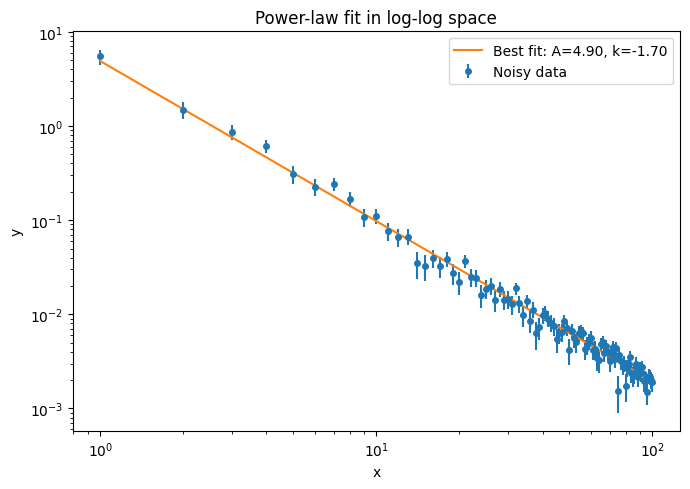

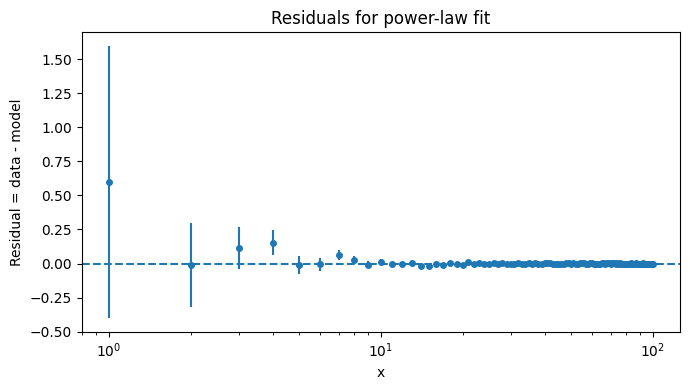

In [6]:
# Plot in loglog - You should see a line

best_y_model = power_law_model(x, best_A, best_k)
residuals = y - best_y_model

plt.figure(figsize=(7,5))
plt.errorbar(x, y, yerr=y_err, fmt='o', markersize=4, label='Noisy data')
plt.plot(x, best_y_model, label=f'Best fit: A={best_A:.2f}, k={best_k:.2f}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Power-law fit in log-log space')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.axhline(0, linestyle='--')
plt.errorbar(x, residuals, yerr=y_err, fmt='o', markersize=4)
plt.xscale('log')
plt.xlabel('x')
plt.ylabel('Residual = data - model')
plt.title('Residuals for power-law fit')
plt.tight_layout()
plt.show()


Comments:

In log-log space, a power law appears as a straight line. The best-fit line follows the data well. The residuals scatter around zero without a strong systematic pattern, so the model is reasonable for this fake data. The reduced \(\chi^2\) is close to 1, meaning the differences between data and model are consistent with the assumed error bars.


We can also see how how $\chi^{2}$ changes as it cycles through the different combinations of parameters. To do this, make a contour plot of $A$ vs $k$ with a colorbar indicating $\chi^{2}$. Include a point indicating your best fit parameters. Comment on the parameter space in relation to thest best-fit values.

Hint: Use LogNorm for the colorbar. The plot should look choppy if you have a low grid resolution, which is fine. If you want, you can make a finer grid, but that will very quickly make the $\chi^{2}$ search become more computationally expensive. 

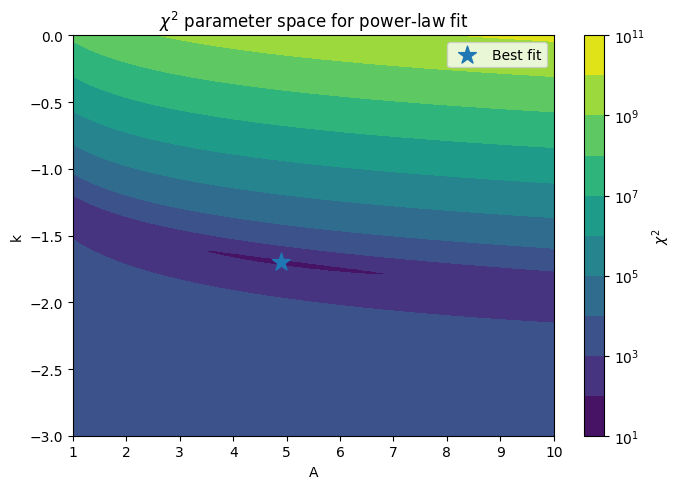

In [7]:
# Contour plot

K_mesh, A_mesh = np.meshgrid(k_grid, A_grid)

plt.figure(figsize=(7,5))
cont = plt.contourf(A_mesh, K_mesh, chi2_grid, levels=40, norm=LogNorm())
plt.colorbar(cont, label=r'$\chi^2$')
plt.scatter(best_A, best_k, marker='*', s=180, label='Best fit')
plt.xlabel('A')
plt.ylabel('k')
plt.title(r'$\chi^2$ parameter space for power-law fit')
plt.legend()
plt.tight_layout()
plt.show()


Comments:

The contour plot shows a clear minimum near the best-fit parameters. The best point is close to the input values used to generate the fake data. The parameter space is not equally good everywhere; only a small region gives low \(\chi^2\). This is why the brute-force search can locate the best parameter combination.


## Real Data [2 pts]
Now let's apply what we've done from before to some real data. Download Stellar_Data.txt which holds mass ($M_{\odot}$), log stellar age (log years), log accretion rate (log $M_{\odot}/yr$), and log accretion rate errors. Note: The data is already in log scale, so how will that change your model function?

In [8]:
# Load in the data

stellar_data = np.loadtxt('HW07_Stellar_Data.txt', skiprows=1)
Mstar = stellar_data[:, 0]
logAge = stellar_data[:, 1]
logMacc = stellar_data[:, 2]
logMaccErr = stellar_data[:, 3]

print(f"Number of stars = {len(logAge)}")
print(f"logAge range = {logAge.min():.2f} to {logAge.max():.2f}")
print(f"logMacc range = {logMacc.min():.2f} to {logMacc.max():.2f}")


Number of stars = 234
logAge range = 5.01 to 7.78
logMacc range = -9.40 to -6.40


In [9]:
# New model function here

# Since the data are already logarithmic, use a straight-line model:
# logMacc = b + m logAge
# Here b is the intercept and m is the slope.

def linear_log_model(log_age, b, m):
    return b + m * log_age


Use the brute force method for two parameters from before. Play around with your parameter space and print out some parameters with their $\chi^{2}$, and $\chi^{2}_{\nu}$. Comment on what you notice about these values.

In [10]:
# Brute force method

b_grid = np.linspace(-12, -2, 401)   # intercept values
m_grid = np.linspace(-1, 1, 401)     # slope values

real_chi2_grid = np.zeros((len(b_grid), len(m_grid)))
real_red_chi2_grid = np.zeros_like(real_chi2_grid)

for i, b_trial in enumerate(b_grid):
    for j, m_trial in enumerate(m_grid):
        model_vals = linear_log_model(logAge, b_trial, m_trial)
        chi2_val = chi_squared(logMacc, model_vals, logMaccErr)
        red_chi2_val = reduced_chi_squared(chi2_val, len(logAge), 2)
        real_chi2_grid[i, j] = chi2_val
        real_red_chi2_grid[i, j] = red_chi2_val

for b_trial, m_trial in [(-8, 0), (-6, -0.3), (-5, -0.6)]:
    model_vals = linear_log_model(logAge, b_trial, m_trial)
    chi2_val = chi_squared(logMacc, model_vals, logMaccErr)
    red_chi2_val = reduced_chi_squared(chi2_val, len(logAge), 2)
    print(f"b = {b_trial:.2f}, m = {m_trial:.2f}, chi^2 = {chi2_val:.3f}, reduced chi^2 = {red_chi2_val:.3f}")


b = -8.00, m = 0.00, chi^2 = 5472.827, reduced chi^2 = 23.590
b = -6.00, m = -0.30, chi^2 = 4542.703, reduced chi^2 = 19.581
b = -5.00, m = -0.60, chi^2 = 20214.592, reduced chi^2 = 87.132


Comments:

The real data produce much larger \(\chi^2\) values than the fake data. This means the simple two-parameter straight-line model does not explain all the scatter in the stellar accretion data. Some points have small error bars, so even moderate residuals can contribute strongly to \(\chi^2\).


Now, find and report the lowest value of $\chi^{2}_{\nu}$ and the corresponding parameters and $\chi^{2}$. These are your best fit parameters.

In [11]:
# Best-fit params

real_best_index = np.unravel_index(np.argmin(real_red_chi2_grid), real_red_chi2_grid.shape)
best_b = b_grid[real_best_index[0]]
best_m = m_grid[real_best_index[1]]
real_best_chi2 = real_chi2_grid[real_best_index]
real_best_red_chi2 = real_red_chi2_grid[real_best_index]

print(f"Best intercept b = {best_b:.4f}")
print(f"Best slope m = {best_m:.4f}")
print(f"Lowest chi^2 = {real_best_chi2:.4f}")
print(f"Lowest reduced chi^2 = {real_best_red_chi2:.4f}")


Best intercept b = -5.8500
Best slope m = -0.3450
Lowest chi^2 = 4065.9121
Lowest reduced chi^2 = 17.5255


As before, plot the data with errors, model with the best-fit parameters, and residuals in log-log space. Make sure to include units on the plot. Comment on the fit. Look back at $\chi^{2}_{\nu}$ value you got, what does this value mean for your model? How could one improve $\chi^{2}_{\nu}$? 

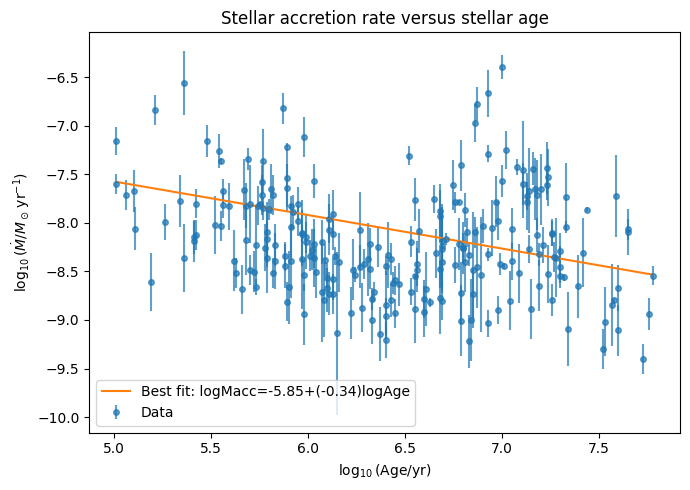

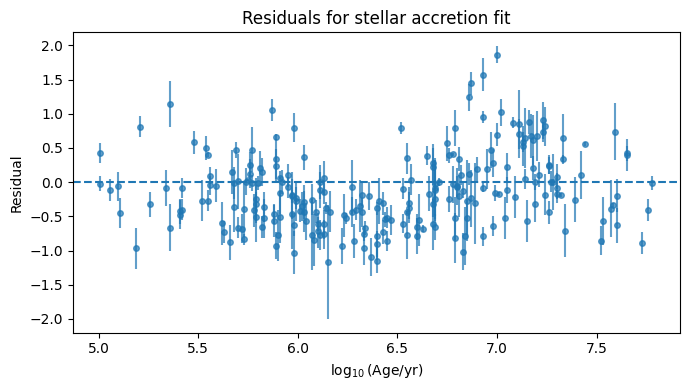

In [12]:
# Plot it up

best_real_model = linear_log_model(logAge, best_b, best_m)
real_residuals = logMacc - best_real_model

x_line = np.linspace(logAge.min(), logAge.max(), 300)
y_line = linear_log_model(x_line, best_b, best_m)

plt.figure(figsize=(7,5))
plt.errorbar(logAge, logMacc, yerr=logMaccErr, fmt='o', markersize=4, alpha=0.7, label='Data')
plt.plot(x_line, y_line, label=f'Best fit: logMacc={best_b:.2f}+({best_m:.2f})logAge')
plt.xlabel(r'$\log_{10}(\mathrm{Age/yr})$')
plt.ylabel(r'$\log_{10}(\dot{M}/M_\odot\,\mathrm{yr}^{-1})$')
plt.title('Stellar accretion rate versus stellar age')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.axhline(0, linestyle='--')
plt.errorbar(logAge, real_residuals, yerr=logMaccErr, fmt='o', markersize=4, alpha=0.7)
plt.xlabel(r'$\log_{10}(\mathrm{Age/yr})$')
plt.ylabel('Residual')
plt.title('Residuals for stellar accretion fit')
plt.tight_layout()
plt.show()


Comments:

The best-fit line shows a negative slope, so the accretion rate generally decreases as stellar age increases. However, the data have a large amount of scatter around the line. The residual plot also shows that many points are far from zero compared with their error bars.


Answers:

The reduced \(\chi^2\) is much larger than 1, so this simple linear model is not a statistically good fit if the listed error bars are the only source of uncertainty. This may mean the model is too simple, the measurements have additional intrinsic scatter, or the errors are underestimated. The fit could be improved by adding an intrinsic scatter term, including stellar mass as another independent variable, removing or modeling outliers carefully, or using a more physically motivated model.


Also, make the contour plot of parameter 1 vs parameter 2 with a colorbar indicating $\chi^{2}$ again. Add the point indicating your best-fit parameters. Comment on the parameter space in relation to these best-fit values. 

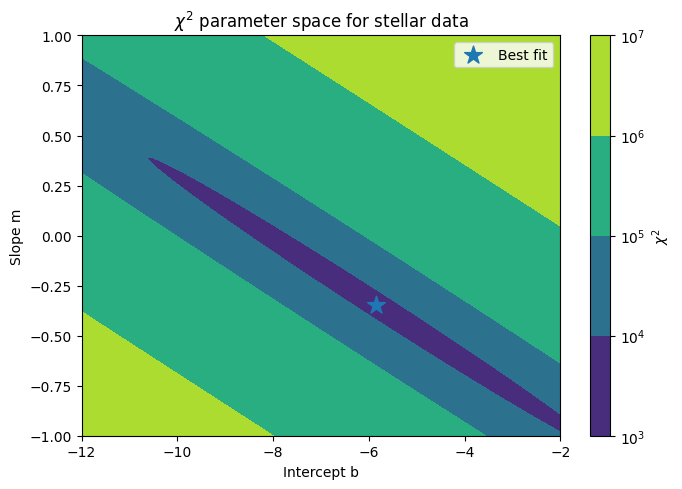

In [13]:
# Contour plot

M_mesh, B_mesh = np.meshgrid(m_grid, b_grid)

plt.figure(figsize=(7,5))
cont = plt.contourf(B_mesh, M_mesh, real_chi2_grid, levels=40, norm=LogNorm())
plt.colorbar(cont, label=r'$\chi^2$')
plt.scatter(best_b, best_m, marker='*', s=180, label='Best fit')
plt.xlabel('Intercept b')
plt.ylabel('Slope m')
plt.title(r'$\chi^2$ parameter space for stellar data')
plt.legend()
plt.tight_layout()
plt.show()


Comments:

The contour plot has a clear minimum near the best-fit intercept and slope. The low-\(\chi^2\) region is elongated, which means the intercept and slope are correlated: changing the slope can be partly compensated by changing the intercept. Even at the minimum, the \(\chi^2\) value is still large, showing that the model itself is limited.


# Fitting Stellar Accretion [5.5 pts]

In this part we are going to be using the the emcee package to run MCMC on a data set for stellar accretion
https://emcee.readthedocs.io/en/stable/

We will work through the steps in https://prappleizer.github.io/Tutorials/MCMC/MCMC_Tutorial_Solution.html to set up the MCMC.

In [14]:
import emcee

First, load Stellar_Data.txt into the notebook and make a scatter plot of logAge vs logMacc. Note: the data is already logarithmic. [0.5 pts]

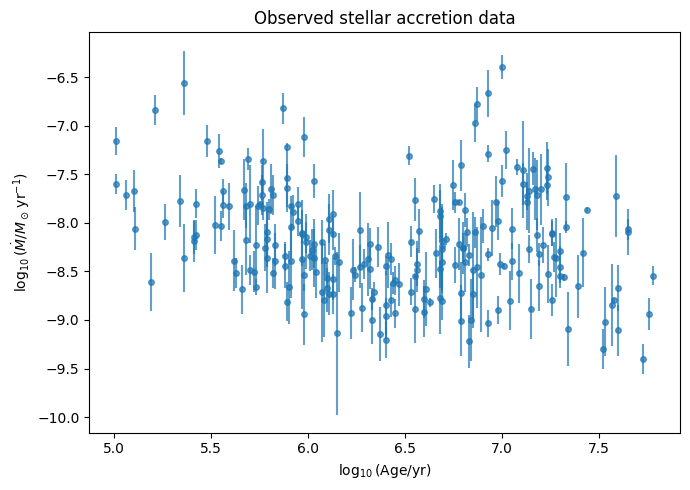

In [15]:
# Load data and plot

stellar_data = np.loadtxt('HW07_Stellar_Data.txt', skiprows=1)
Mstar = stellar_data[:, 0]
logAge = stellar_data[:, 1]
logMacc = stellar_data[:, 2]
logMaccErr = stellar_data[:, 3]

plt.figure(figsize=(7,5))
plt.errorbar(logAge, logMacc, yerr=logMaccErr, fmt='o', markersize=4, alpha=0.7)
plt.xlabel(r'$\log_{10}(\mathrm{Age/yr})$')
plt.ylabel(r'$\log_{10}(\dot{M}/M_\odot\,\mathrm{yr}^{-1})$')
plt.title('Observed stellar accretion data')
plt.tight_layout()
plt.show()


Create the linear model definition, the log likelihood definition, the lnprior definition, and the posterior probability definition. [1 pnt]

In [16]:
# Linear Model Def

def model(theta, x):
    b, m = theta
    return b + m * x

# Log Likelihood Def

def log_likelihood(theta, x, y, yerr):
    y_model = model(theta, x)
    return -0.5 * np.sum(((y - y_model) / yerr)**2 + np.log(2 * np.pi * yerr**2))

# lnprior Def

def log_prior(theta):
    b, m = theta
    if -12 < b < -2 and -1 < m < 1:
        return 0.0
    return -np.inf

# Posterior Prob Def

def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)


Use the definitions to run the emcee. Your number of walkers should be some power of 2, and your number of iterations should be some value over 100. [1 pts]

In [17]:
# Parameters

# If emcee is not installed, run this once in a notebook cell:
# !pip install emcee

ndim = 2
nwalkers = 32
nsteps = 2000

# Start walkers near the brute-force best fit.
initial_guess = np.array([best_b, best_m])
pos = initial_guess + 1e-3 * np.random.randn(nwalkers, ndim)

# Run MCMC
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(logAge, logMacc, logMaccErr))
sampler.run_mcmc(pos, nsteps, progress=True)

print('MCMC finished.')


MCMC finished.


Make a plot of the parameters' values over each step (typically referred to as a convergence or trace study). Comment on the value of the parameters as the MCMC runs. Hint: This information is encoded in the get_chain() function. [1 pnt]

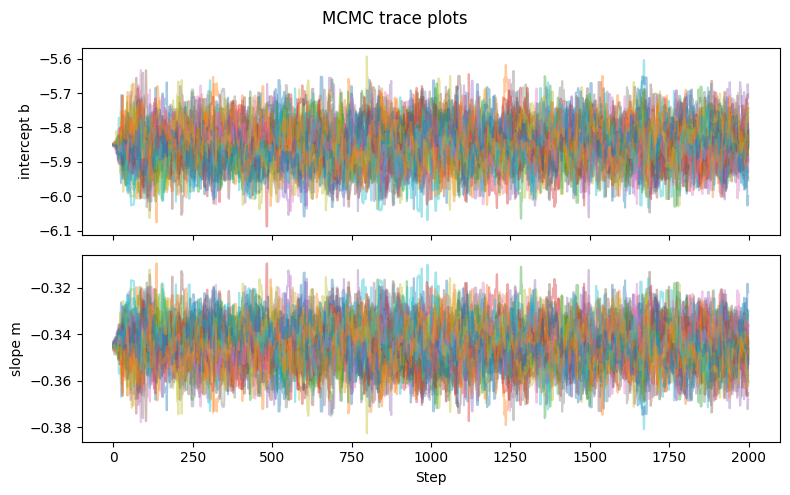

In [18]:
# Plot parameter values versus steps (iterations)

chain = sampler.get_chain()
labels = ['intercept b', 'slope m']

fig, axes = plt.subplots(ndim, figsize=(8, 5), sharex=True)
for i in range(ndim):
    axes[i].plot(chain[:, :, i], alpha=0.4)
    axes[i].set_ylabel(labels[i])
axes[-1].set_xlabel('Step')
plt.suptitle('MCMC trace plots')
plt.tight_layout()
plt.show()


Comments:

The trace plots show that the walkers quickly settle into stable regions for both parameters. The intercept fluctuates around about $-5.85$ and the slope fluctuates around about $-0.345$. There is no strong long-term drift after the initial part of the chain, so the MCMC appears to have reached a stable sampling region.


After running emcee, plot the original data with the best fit line calculated from the emcee. Comment on the plot. [1 pnt]


MCMC intercept b = -5.8485 (+0.0615, -0.0623)
MCMC slope m = -0.3446 (+0.0096, -0.0096)


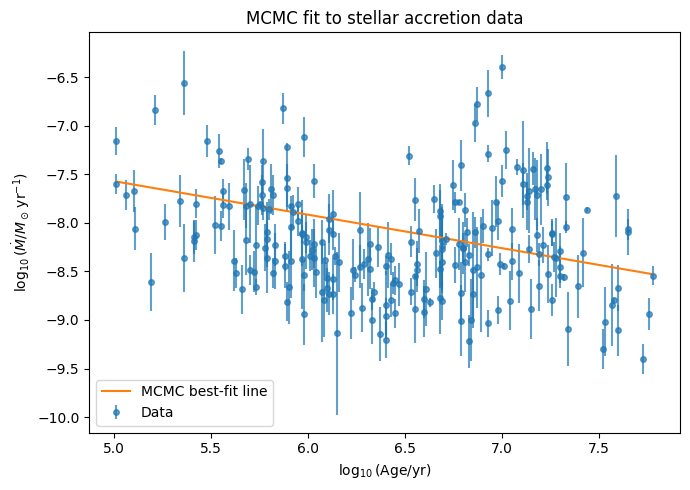

In [19]:
# Plot data and best-fit line

# Remove burn-in and flatten the chains.
flat_samples = sampler.get_chain(discard=500, thin=10, flat=True)

b_mcmc, m_mcmc = np.median(flat_samples, axis=0)
b_lower, m_lower = np.percentile(flat_samples, 16, axis=0)
b_upper, m_upper = np.percentile(flat_samples, 84, axis=0)

print(f"MCMC intercept b = {b_mcmc:.4f} (+{b_upper-b_mcmc:.4f}, -{b_mcmc-b_lower:.4f})")
print(f"MCMC slope m = {m_mcmc:.4f} (+{m_upper-m_mcmc:.4f}, -{m_mcmc-m_lower:.4f})")

x_line = np.linspace(logAge.min(), logAge.max(), 300)
y_mcmc_line = model([b_mcmc, m_mcmc], x_line)

plt.figure(figsize=(7,5))
plt.errorbar(logAge, logMacc, yerr=logMaccErr, fmt='o', markersize=4, alpha=0.7, label='Data')
plt.plot(x_line, y_mcmc_line, label='MCMC best-fit line')
plt.xlabel(r'$\log_{10}(\mathrm{Age/yr})$')
plt.ylabel(r'$\log_{10}(\dot{M}/M_\odot\,\mathrm{yr}^{-1})$')
plt.title('MCMC fit to stellar accretion data')
plt.legend()
plt.tight_layout()
plt.show()


Comments:

The MCMC best-fit line is very similar to the brute-force best-fit line. It captures the general decreasing trend of accretion rate with age, but it cannot explain all of the scatter. The spread of points around the line is much larger than expected from many of the plotted error bars.


Finally, use the original data, its errors, and the emcee model data to calculate $\chi^{2}$ and $\chi^{2}_{v}$. Comment on the results. [1 pnt]

In [20]:
# Calculate chi-squared

emcee_model_data = model([b_mcmc, m_mcmc], logAge)
chi2_mcmc = chi_squared(logMacc, emcee_model_data, logMaccErr)

# Calculate reduced chi-squared

red_chi2_mcmc = reduced_chi_squared(chi2_mcmc, len(logAge), ndim)

print(f"MCMC chi^2 = {chi2_mcmc:.4f}")
print(f"MCMC reduced chi^2 = {red_chi2_mcmc:.4f}")


MCMC chi^2 = 4065.6695
MCMC reduced chi^2 = 17.5244


Comments:

The MCMC fit gives a reduced \(\chi^2\) much greater than 1, similar to the brute-force result. Therefore, the best straight-line model is not sufficient to describe the stellar accretion data within the quoted measurement errors. A better analysis should include intrinsic scatter and possibly additional physical variables such as stellar mass.
